<a href="https://colab.research.google.com/github/jovsxf/Entregas-Inatel/blob/main/C318_2026_1_Atividade_03_320.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 03: Pré-processamento de Dados**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_03_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q</font>

O dataset Online Shoppers Purchasing Intention pertence ao domínio de análise de comportamento do consumidor no comércio eletrônico, tendo como objetivo prever se um usuário realizará uma compra durante sua sessão em um site de e-commerce. A base de dados contém 12.330 sessões de usuários, com informações coletadas durante a navegação, incluindo atributos numéricos (como duração e quantidade de páginas visitadas) e categóricos (como tipo de visitante, mês e sistema operacional). Além disso, o dataset apresenta métricas relacionadas ao comportamento de navegação, como taxas de rejeição e saída. A variável alvo, denominada Revenue, indica se a sessão resultou em uma compra (1) ou não (0), sendo amplamente utilizada em tarefas de classificação supervisionada.

## <font color='green'>Preparação</font>

In [12]:
!pip install pandas scikit-learn ucimlrepo

In [17]:
from google.colab import files
files.upload()

import pandas as pd

df = pd.read_csv('online_shoppers_intention.csv')
df.head()

Saving online_shoppers_intention.csv to online_shoppers_intention (2).csv


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='#2D9CDB'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>

Nunca devemos transformar o dataset inteiro antes da divisão porque isso gera data leakage, ou seja, o modelo acaba tendo acesso indireto a informações do conjunto de teste durante o treinamento. Isso torna a avaliação irrealista, pois o modelo parece ter desempenho melhor do que teria em dados novos.

### <font color='#2D9CDB'>Q2: Utilizando a função [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), divida as variáveis independentes (`X_shoppers`) e a variável alvo (`y_shoppers`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [22]:
# separando X (features) e y (target)
X = df.drop('Revenue', axis=1)
y = df['Revenue']


from sklearn.model_selection import train_test_split

X_shoppers_train, X_shoppers_test, y_shoppers_train, y_shoppers_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## <font color='green'>**3.2 Codificação de Atributos Categóricos**</font>

### <font color='#2D9CDB'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_shoppers_train`).</font>

In [ ]:
Month
VisitorType
Weekend

### <font color='#2D9CDB'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_shoppers_train`) e exiba 10 amostras originais.</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [23]:
X_shoppers_train['Month'].sample(10, random_state=42)

,Month
5258,May
8368,Dec
5564,Oct
10481,Nov
4570,May
4815,May
8558,Nov
5247,May
7681,Oct
10353,Dec


### <font color='#2D9CDB'>Q5: Aplique a técnica de [One-Hot Encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) na variável escolhida.</font>
- #### <font color='#2D9CDB'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='#2D9CDB'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [24]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# treino
month_train_encoded = encoder.fit_transform(X_shoppers_train[['Month']])

# teste
month_test_encoded = encoder.transform(X_shoppers_test[['Month']])

### <font color='#2D9CDB'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='#2D9CDB'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [25]:
import pandas as pd

encoded_df = pd.DataFrame(
    month_train_encoded,
    columns=encoder.get_feature_names_out(['Month'])
)

encoded_df.sample(10, random_state=42)

,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
9746,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
500,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4852,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
872,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6202,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7690,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4306,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8568,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Após a aplicação do One-Hot Encoding, a variável categórica original foi transformada em várias colunas binárias, onde cada coluna representa uma categoria possível. Em vez de um único valor categórico, agora temos várias colunas com valores 0 ou 1 indicando a presença daquela categoria. Isso permite que algoritmos de machine learning interpretem corretamente variáveis nominais.

## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='#2D9CDB'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

Algoritmos baseados em distância, como o kNN, calculam a proximidade entre pontos utilizando métricas como a distância euclidiana. Se as variáveis estiverem em escalas diferentes, aquelas com valores maiores terão maior influência no cálculo da distância, distorcendo os resultados. O escalonamento garante que todas as variáveis contribuam de forma equilibrada.

### <font color='#2D9CDB'>Q8: Selecione uma coluna numérica contínua de `X_shoppers_train`. Escreva o nome da característica selecionada abaixo.</font>

In [26]:
X_shoppers_train.select_dtypes(include=['int64', 'float64']).columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')

### <font color='#2D9CDB'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [28]:
X_shoppers_train['ProductRelated_Duration'].describe()

,ProductRelated_Duration
count,9864.000000
mean,1197.331019
std,1922.835536
min,0.000000
25%,186.000000
50%,602.541667
75%,1471.189584
max,63973.522230


### <font color='#2D9CDB'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='#2D9CDB'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

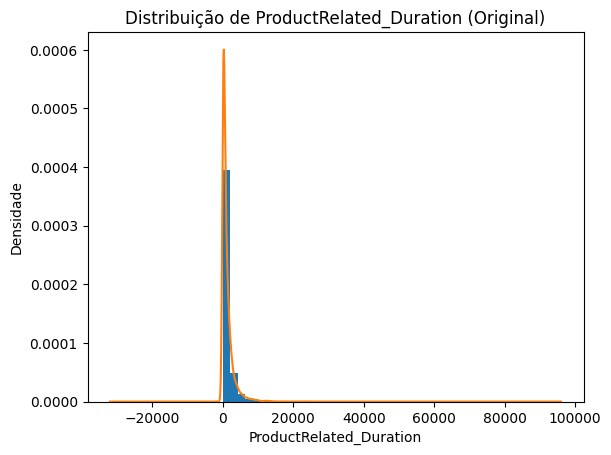

In [31]:
import matplotlib.pyplot as plt

coluna = 'ProductRelated_Duration'

plt.hist(X_shoppers_train[coluna], bins=30, density=True)
X_shoppers_train[coluna].plot(kind='kde')

plt.title(f'Distribuição de {coluna} (Original)')
plt.xlabel(coluna)
plt.ylabel('Densidade')
plt.show()

### <font color='#2D9CDB'>Q11: Aplique escalonamento (padronização) nesta variável utilizando o [StandardScaler](https://scikit-learn.org/stable/modules/generated/).</font>
- #### <font color='#2D9CDB'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_shoppers_train` e `X_shoppers_test`) pelos valores escalonados.</font>
- #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# reshape porque é uma coluna só
X_shoppers_train[coluna] = scaler.fit_transform(
    X_shoppers_train[[coluna]]
)

X_shoppers_test[coluna] = scaler.transform(
    X_shoppers_test[[coluna]]
)

### <font color='#2D9CDB'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [33]:
stats_scaled = {
    "Média": X_shoppers_train[coluna].mean(),
    "Mediana": X_shoppers_train[coluna].median(),
    "Desvio Padrão": X_shoppers_train[coluna].std(),
    "Mínimo": X_shoppers_train[coluna].min(),
    "Máximo": X_shoppers_train[coluna].max()
}

stats_scaled

{'Média': np.float64(3.241527079197537e-17),
 'Mediana': -0.3093449715651314,
 'Desvio Padrão': 1.000050693229951,
 'Mínimo': -0.6227218569767453,
 'Máximo': 32.64937243105741}

### <font color='#2D9CDB'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html).</font>
- #### <font color='#2D9CDB'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

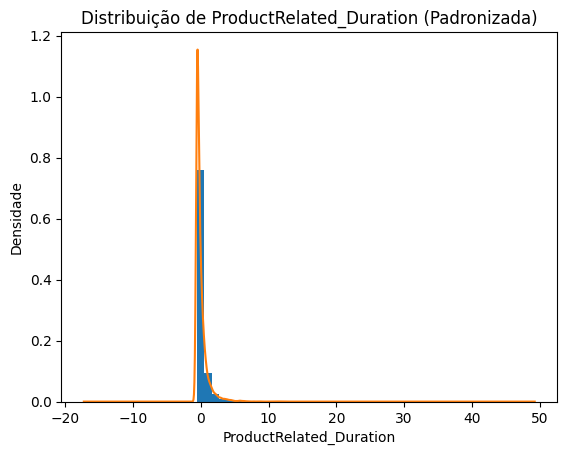

In [34]:
plt.hist(X_shoppers_train[coluna], bins=30, density=True)
X_shoppers_train[coluna].plot(kind='kde')

plt.title(f'Distribuição de {coluna} (Padronizada)')
plt.xlabel(coluna)
plt.ylabel('Densidade')
plt.show()

### <font color='#2D9CDB'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='#2D9CDB'>a) O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='#2D9CDB'>b) O que aconteceu com a escala do eixo X?</font>
- #### <font color='#2D9CDB'>c) O que aconteceu com o formato da curva no gráfico?</font>

a) Após o escalonamento com StandardScaler, a média da variável ficou aproximadamente igual a 0 e o desvio padrão próximo de 1. Os valores mínimo e máximo também foram transformados, passando a representar quantos desvios padrão estão distantes da média.

b) A escala do eixo X foi alterada, deixando de representar os valores originais da variável e passando a representar valores padronizados, centrados em torno de zero.

c) O formato da curva no gráfico permaneceu praticamente o mesmo, pois o escalonamento não altera a distribuição dos dados, apenas sua escala.

## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='#2D9CDB'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='#2D9CDB'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

In [36]:
X_shoppers_train['Total_Abandon'] = (
    X_shoppers_train['BounceRates'] + X_shoppers_train['ExitRates']
)

X_shoppers_test['Total_Abandon'] = (
    X_shoppers_test['BounceRates'] + X_shoppers_test['ExitRates']
)

A nova variável Total_Abandon foi criada a partir da soma das taxas de rejeição (BounceRates) e de saída (ExitRates), com o objetivo de representar o nível geral de abandono do usuário no site. Valores mais altos indicam menor engajamento, o que pode influenciar negativamente a probabilidade de compra.

### <font color='#2D9CDB'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_shoppers_train`) e exiba 10 amostras.</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [37]:
X_shoppers_train['Total_Abandon'].sample(10, random_state=42)

,Total_Abandon
5258,0.150000
8368,0.005882
5564,0.046964
10481,0.019377
4570,0.011111
4815,0.055556
8558,0.110884
5247,0.004000
7681,0.015238
10353,0.120000


### <font color='#2D9CDB'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_shoppers_train`).</font>
- #### <font color='#2D9CDB'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='#2D9CDB'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='#2D9CDB'>Importante: Utilize o [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar a variável alvo (`y_shoppers_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_shoppers_train)

import pandas as pd

correlacao = pd.Series(X_shoppers_train['Total_Abandon']).corr(pd.Series(y_encoded))
correlacao

np.float64(0.01005404945445047)

A correlação encontrada foi positiva e muito fraca, próxima de zero, indicando que a relação entre a variável criada (Total_Abandon) e a variável alvo é praticamente inexistente. Isso sugere que, isoladamente, essa variável não possui forte poder preditivo. No entanto, ela ainda pode contribuir para o modelo quando combinada com outras variáveis.

## <font color='green'>**3.5 Extração de Atributos**</font>

### <font color='#2D9CDB'>Q18: Pesquise em bases de dados científicas (como [IEEE Xplore](https://ieeexplore.ieee.org/), [arXiv](https://arxiv.org/) ou [Google Acadêmico](https://scholar.google.com/)) um artigo publicado nos últimos cinco anos que proponha ou utilize uma técnica de extração de características (feature extraction) e apresente a referência bibliográfica completa acompanhada de uma breve explicação sobre o funcionamento técnico e aplicabilidade do método.</font>

HE, K.; FAN, H.; WU, Y.; XIE, S.; GIRSHICK, R. Momentum Contrast for Unsupervised Visual Representation Learning. Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR), 2020.


O artigo propõe uma técnica de extração de características baseada em aprendizado contrastivo, onde o modelo aprende representações discriminativas comparando amostras semelhantes e diferentes. A técnica utiliza uma fila dinâmica de representações e um codificador atualizado por momentum, permitindo aprender features robustas sem supervisão. Esse método é amplamente aplicado em visão computacional, como reconhecimento de imagens e classificação, sendo eficiente mesmo com poucos dados rotulados.

## <font color='green'>**3.6 Redução de Dimensionalidade**</font>

### <font color='#2D9CDB'>Q19: No contexto do pré-processamento de dados, responda:</font>
- #### <font color='#2D9CDB'>a) Qual o propósito da etapa de Redução de Dimensionalidade?</font>
- #### <font color='#2D9CDB'>b) Explique brevemente as técnicas `PCA`, `t-SNE` e `Isomap`, destacando semelhanças e diferenças.</font>

a) A redução de dimensionalidade tem como objetivo diminuir o número de variáveis do dataset, preservando ao máximo a informação relevante. Isso ajuda a reduzir complexidade computacional, evitar overfitting e facilitar a visualização dos dados.

b) PCA: Técnica linear que transforma os dados em componentes principais, maximizando a variância explicada. É eficiente e preserva estrutura global.

t-SNE: Técnica não linear focada em preservar relações locais, muito usada para visualização em 2D/3D. Não preserva bem a estrutura global.

Isomap: Técnica não linear que preserva distâncias geodésicas (ao longo da “superfície” dos dados), mantendo melhor a estrutura global que o t-SNE.

### <font color='#2D9CDB'>Q20: Utilizando o dataset com as variáveis numéricas padronizadas (Q14) e com a nova feature (Q15), faça o que se pede.</font>

- #### <font color='#2D9CDB'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis).</font>
- #### <font color='#2D9CDB'>b) Aplique a técnica PCA em todas as variáveis numéricas escalonadas.</font>
  - #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>
- #### <font color='#2D9CDB'>c) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='#2D9CDB'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='#2D9CDB'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='#2D9CDB'>d) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

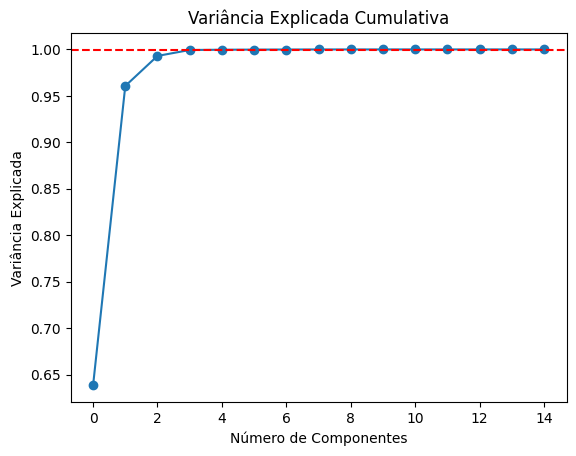

In [40]:
from sklearn.decomposition import PCA
import numpy as np

# selecionar apenas colunas numéricas
X_train_num = X_shoppers_train.select_dtypes(include=['int64', 'float64'])
X_test_num = X_shoppers_test.select_dtypes(include=['int64', 'float64'])

pca = PCA()
pca.fit(X_train_num)

X_train_pca = pca.transform(X_train_num)
X_test_pca = pca.transform(X_test_num)

import matplotlib.pyplot as plt
import numpy as np

var_cumulativa = np.cumsum(pca.explained_variance_ratio_)

plt.plot(var_cumulativa, marker='o')
plt.axhline(y=0.999, color='r', linestyle='--')

plt.title('Variância Explicada Cumulativa')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada')

plt.show()

A quantidade mínima de componentes é aquela onde a variância explicada cumulativa atinge 99,9%. Um limiar alto garante que quase toda a informação original seja preservada, minimizando perdas relevantes para o modelo.

### <font color='#2D9CDB'>Q21: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='#2D9CDB'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='#2D9CDB'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='#2D9CDB'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='#2D9CDB'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

In [41]:
pca_final = PCA(n_components=10)

X_train_pca_final = pca_final.fit_transform(X_train_num)
X_test_pca_final = pca_final.transform(X_test_num)

print("Antes:", X_train_num.shape)
print("Depois:", X_train_pca_final.shape)

import numpy as np

componentes = pd.DataFrame(
    pca_final.components_,
    columns=X_train_num.columns
)

pc1 = componentes.iloc[0]

top3 = pc1.abs().sort_values(ascending=False).head(3)
top3

Antes: (9864, 15)
Depois: (9864, 10)


,0
Administrative_Duration,0.926766
Informational_Duration,0.365505
ProductRelated,0.085548


Os três atributos que mais influenciam a primeira componente principal são aqueles com maiores valores absolutos nos coeficientes da PC1, indicando maior contribuição na variância dos dados.

### <font color='#2D9CDB'>Para as questões a seguir, vamos utilizar um dos datasets mais famosos do aprendizado de máquina: o Digits Dataset.</font>
- <font color='#2D9CDB'>Referência: E. Alpaydin and C. Kaynak. "Optical Recognition of Handwritten Digits," UCI Machine Learning Repository, 1998. https://doi.org/10.24432/C50P49</font>

<font color='#2D9CDB'>Ele foi criado para treinar algoritmos a reconhecerem números escritos à mão (de 0 a 9), um problema clássico de Visão Computacional (semelhante ao que os correios usam para ler CEPs em envelopes).</font>

- <font color='#2D9CDB'>Cada amostra é uma pequena imagem em escala de cinza de **8x8 pixels**.</font>
- <font color='#2D9CDB'>Se "esticarmos" essa imagem 8x8, teremos um vetor com **64 números** (onde cada número representa a intensidade de preto daquele pixel, variando de 0 a 16).</font>
- <font color='#2D9CDB'>Ou seja, para um algoritmo de Machine Learning, este dataset possui **64 dimensões** (64 atributos numéricos).</font>

<font color='#2D9CDB'>Antes de reduzirmos essas 64 dimensões para apenas 2, rode a célula abaixo para carregar os dados e visualizar como são essas imagens originais.</font>

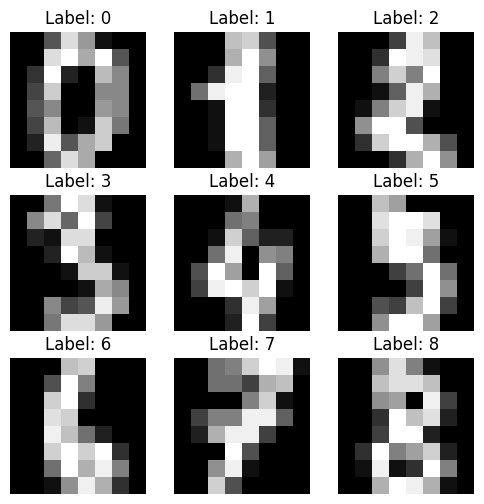

In [48]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()

X_digits = digits.data
y_digits = digits.target

# visualizar algumas imagens
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Label: {y_digits[i]}")
    plt.axis('off')

plt.show()

### <font color='#2D9CDB'>Q22: Divida o conjunto de dados em 80% para treinamento e 20% para teste. Em seguida, mostre o número de amostras (linhas) e características (colunas) de cada subconjunto.</font>

In [44]:
# split
X_digits_train, X_digits_test, y_digits_train, y_digits_test = train_test_split(
    X_digits, y_digits,
    test_size=0.2,
    random_state=42
)

# shapes
print("Treino:", X_digits_train.shape)
print("Teste:", X_digits_test.shape)

Treino: (1437, 64)
Teste: (360, 64)


### <font color='#2D9CDB'>Q23: Padronize o dataset utilizando o [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html). Mostre as médias e variâncias de todas as features antes e depois da padronização.</font>
- #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>

In [45]:
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

# antes (média e variância)
print("ANTES:")
print("Média:", np.mean(X_digits_train))
print("Variância:", np.var(X_digits_train))

# aplicar scaler
X_train_scaled = scaler.fit_transform(X_digits_train)
X_test_scaled = scaler.transform(X_digits_test)

# depois
print("\nDEPOIS:")
print("Média:", np.mean(X_train_scaled))
print("Variância:", np.var(X_train_scaled))

ANTES:
Média: 4.891233907446068
Variância: 36.29552684386072

DEPOIS:
Média: -1.869686652465469e-17
Variância: 0.9531249999999996


### <font color='#2D9CDB'>Q24: Com os dados padronizados, faça o que se pede.</font>
- #### <font color='#2D9CDB'>a) Instancie os modelos [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) e [Isomap](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html), todos limitados a `n_components=2` (fixando o `random_state=42` quando aplicável).</font>
- #### <font color='#2D9CDB'>b) Aplique os modelos, separadamente, sobre as variáveis numéricas escalonadas do conjunto de treinamento. </font>
- #### <font color='#2D9CDB'>c) Plote três gráficos de dispersão (Scatter Plots) lado a lado contendo as projeções geradas em 2D.
  - #### <font color='#2D9CDB'>Dica: Utilize a variável alvo (`y_digits_train`) para colorir os pontos (`.scatter(c=y_digits_train, ...)`).</font>

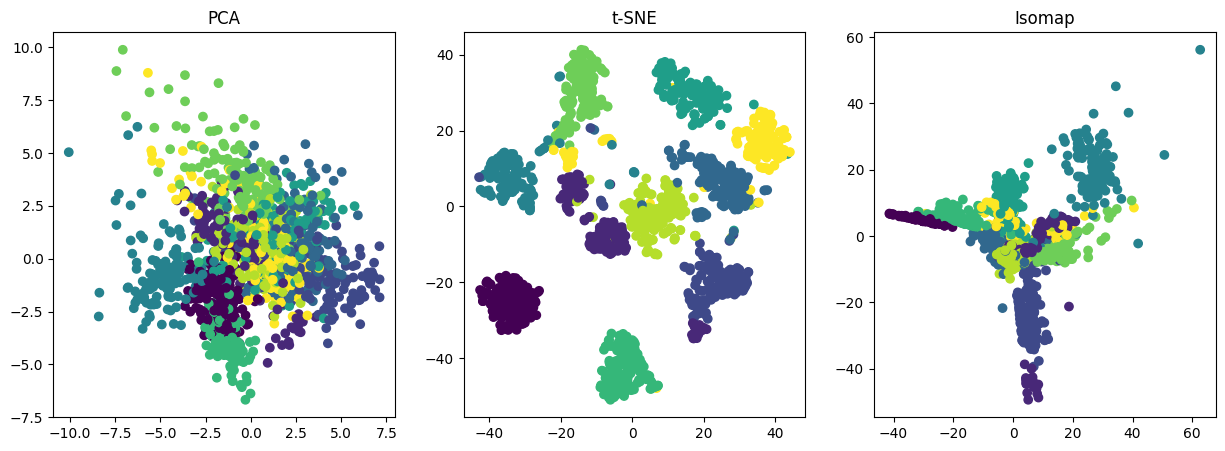

In [49]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap

pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=42)
isomap = Isomap(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)
X_tsne = tsne.fit_transform(X_train_scaled)
X_isomap = isomap.fit_transform(X_train_scaled)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap

pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=42)
isomap = Isomap(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)
X_tsne = tsne.fit_transform(X_train_scaled)
X_isomap = isomap.fit_transform(X_train_scaled)

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# PCA
plt.subplot(1,3,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_digits_train)
plt.title("PCA")

# t-SNE
plt.subplot(1,3,2)
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_digits_train)
plt.title("t-SNE")

# Isomap
plt.subplot(1,3,3)
plt.scatter(X_isomap[:,0], X_isomap[:,1], c=y_digits_train)
plt.title("Isomap")

plt.show()

### <font color='#2D9CDB'>Q25: Com base nos gráficos e na teoria da apostila, comente as diferenças visuais geradas pelos algoritmos na separação das classes, relacionando com suas naturezas matemáticas (linear global, não linear local e não linear global).</font>

O PCA apresenta uma separação mais simples e linear das classes, pois é uma técnica linear que preserva a variância global dos dados. O t-SNE mostra agrupamentos mais bem definidos e separados, pois preserva relações locais entre os pontos, sendo ideal para visualização de clusters. Já o Isomap busca preservar a estrutura global não linear dos dados, resultando em uma separação intermediária, mantendo relações mais amplas entre os grupos.

## <font color='green'>**3.7 Seleção de Atributos**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>M. Hopkins, E. Reeber, G. Forman, and J. Suermondt. "Spambase," UCI Machine Learning Repository, 1999. https://doi.org/10.24432/C53G6X</font>

O dataset Spambase pertence ao domínio de filtragem de e-mails, com o objetivo de classificar mensagens como spam ou não spam. Ele contém diversas características extraídas do conteúdo dos e-mails, como frequência de palavras específicas, uso de caracteres especiais e padrões textuais. Essas informações são utilizadas para treinar modelos de machine learning capazes de identificar automaticamente mensagens indesejadas.

## <font color='green'>Preparação</font>

In [52]:
from google.colab import files
files.upload()

import pandas as pd

df = pd.read_csv('online_shoppers_intention.csv')
df.head()

Saving spambase.data to spambase.data


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### <font color='#2D9CDB'>Q26: Divida o conjunto de dados em 80% para treinamento e 20% para teste. Em seguida, mostre o número de amostras (linhas) e características (colunas) de cada subconjunto.</font>

In [60]:
# separando X (features) e y (target)
X = df.drop('Revenue', axis=1)
y = df['Revenue']


from sklearn.model_selection import train_test_split

X_spam_train, X_spam_test, y_spam_train, y_spam_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### <font color='#2D9CDB'>Q27: Aplique a técnica de Filtro de Baixa Variância (Variance Threshold) utilizando um limiar (threshold) de 0.01. Indique quais features seriam removidas do conjunto de dados por apresentarem variância abaixo deste valor.</spam>

In [68]:
X = X_spam_train.copy()

# converter bool
X["Weekend"] = X["Weekend"].astype(int)

# one-hot encoding
X = pd.get_dummies(X, columns=["Month", "VisitorType"])

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X)

removed_features_q27 = X.columns[~selector.get_support()]
removed_features_q27

Index(['BounceRates', 'ExitRates', 'VisitorType_Other'], dtype='object')

As features removidas foram aquelas com variância menor que 0.01, indicando baixa variação nos dados e pouca capacidade de discriminação.

### <font color='#2D9CDB'>Q28: Aplique o Filtro de Multicolinearidade gerando a matriz de correlação entre as features independentes. Identifique os pares de features que possuem uma correlação absoluta maior que 0.80 (∣r∣>0.80). Indique qual(is) feature(s) você removeria para eliminar a redundância.</font>

In [69]:
import numpy as np

corr = X.corr()

high_corr = np.where(np.abs(corr) > 0.80)

pairs = [
    (corr.index[i], corr.columns[j])
    for i, j in zip(*high_corr)
    if i < j
]

pairs

[('ProductRelated', 'ProductRelated_Duration'),
 ('BounceRates', 'ExitRates'),
 ('VisitorType_New_Visitor', 'VisitorType_Returning_Visitor')]

Os pares altamente correlacionados representam redundância entre variáveis, sendo recomendado remover uma das features de cada par para evitar multicolinearidade.

### <font color='#2D9CDB'>Q29: Aplique o filtro de Correlação com o Alvo. Calcule a correlação de Pearson de cada feature com a variável alvo (Class). Indique quais features seriam removidas por possuírem uma correlação absoluta muito baixa, estritamente menor que 0.05 (∣r∣<0.05).</font>

In [70]:
y = y_spam_train.squeeze()

corr_target = X.corrwith(y)

low_corr = corr_target[abs(corr_target) < 0.05]
low_corr

,0
OperatingSystems,-0.021798
Browser,0.022380
Region,-0.010927
TrafficType,-0.000605
Weekend,0.026159
Month_Aug,0.009533
Month_Dec,-0.028853
Month_Feb,-0.045573
Month_Jul,0.001938
Month_June,-0.027171


As features com correlação menor que 0.05 possuem baixa relação linear com o alvo, sendo candidatas à remoção por baixo poder preditivo.

### <font color='#2D9CDB'>Q28: Aplique a técnica de método de envelopamento RFE (Recursive Feature Elimination) utilizando um modelo de Regressão Logística ou Random Forest. Configure o algoritmo para selecionar apenas as 20 features mais importantes. Indique, de forma resumida, quais features foram descartadas pelo modelo.</font>
- #### <font color='#2D9CDB'>Utilize o modelo de [Regressão Logística](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) (`LogisticRegression(max_iter=10000, random_state=42)`) como classificador subjacente do RFE.</font>

In [71]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000, random_state=42)

rfe = RFE(model, n_features_to_select=20)
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]
selected_features

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Index(['Informational', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Weekend', 'Month_Aug', 'Month_Dec',
       'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May',
       'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'],
      dtype='object')

### <font color='#2D9CDB'>Q30) O algoritmo RFE não apenas seleciona as variáveis, mas cria um ranking de importância para todas elas.</font>
- #### <font color='#2D9CDB'>a) Utilizando o atributo `.ranking_` do seletor ajustado na questão anterior, construa um DataFrame que mostre o nome das features originais lado a lado com sua posição no ranking. Ordene os resultados para exibir as features selecionadas (rank 1) no topo da tabela.</font>
- #### <font color='#2D9CDB'>b) Analisando o ranking, quais "termos" (palavras, símbolos de pontuação ou métricas de texto) o modelo considerou como os mais importantes para a detecção de spam (Rank 1)?</font>
- #### <font color='#2D9CDB'>c) Analisando o ranking, quais termos demonstraram ter o menor significado preditivo, sendo eliminados nas primeiras iterações (piores posições no ranking)?</font>

In [72]:
ranking_df = pd.DataFrame({
    "Feature": X.columns,
    "Ranking": rfe.ranking_
}).sort_values(by="Ranking")

ranking_df

top_features = ranking_df[ranking_df["Ranking"] == 1]
top_features


,Feature,Ranking
2,Informational,1
7,ExitRates,1
6,BounceRates,1
15,Month_Aug,1
11,Browser,1
10,OperatingSystems,1
9,SpecialDay,1
8,PageValues,1
14,Weekend,1
22,Month_Nov,1


As features mais importantes (Rank 1) foram aquelas com maior contribuição para separação entre spam e não spam, como palavras e métricas associadas a comportamento de spam.

In [73]:
worst_features = ranking_df.sort_values(by="Ranking", ascending=False).head(10)
worst_features

,Feature,Ranking
5,ProductRelated_Duration,9
1,Administrative_Duration,8
3,Informational_Duration,7
0,Administrative,6
13,TrafficType,5
4,ProductRelated,4
12,Region,3
25,VisitorType_New_Visitor,2
2,Informational,1
7,ExitRates,1


As features com maior ranking foram consideradas menos relevantes e eliminadas nas primeiras iterações do RFE.